Relationship between INTs and model Parameters

In [ ]:
# Imports
import numpy as np
from hbnm.io import Data
from hbnm.bnm import Bnm
from experiments.Model_Picker.picker_utils import find_fixed_point, compute_jacobian, analyze_jacobian_structure, eigen_analysis, analyze_eigenspectrum
from tqdm import tqdm


In [ ]:
# Define data object
input_dir = '/home/frank/HBNM/data/'
output_dir = '/home/frank/HBNM/outputs/'
data = Data(input_dir, output_dir)
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() 


In [ ]:
# Helper functions for timescale analysis
def compute_excitatory_timescales(eigenvalues, eigenvectors, n_regions=180):
    """
    Compute timescales for excitatory firing rate dynamics
    
    The excitatory firing rates r_E depend on both S_E and S_I through:
    r_E = φ_E(I_E) where I_E = f(S_E, S_I)
    
    We extract the excitatory component from each eigenmode.
    """
    # Only consider stable modes (Re(λ) < 0)
    stable_mask = eigenvalues.real < 0
    stable_eigenvals = eigenvalues[stable_mask]
    stable_eigenvecs = eigenvectors[:, stable_mask]
    
    # Modal timescales
    modal_timescales = -1.0 / stable_eigenvals.real
    
    # Extract ONLY the excitatory components (indices 0-179)
    excitatory_eigenvecs = stable_eigenvecs[:n_regions, :]  # First 180 rows
    
    # For each region, compute participation-weighted timescale
    regional_timescales = np.zeros(n_regions)
    
    for region in range(n_regions):
        # Weight by squared magnitude of excitatory eigenvector component
        region_weights = np.abs(excitatory_eigenvecs[region, :])**2
        
        # Compute weighted average timescale (only excitatory contribution)
        if np.sum(region_weights) > 0:
            regional_timescales[region] = np.average(modal_timescales, weights=region_weights)
        else:
            regional_timescales[region] = np.nan
            
    return regional_timescales, modal_timescales


### Test Basic Single Node Model

In [ ]:
# Parallel Processing Implementation for High-Performance Grid Search
from joblib import Parallel, delayed
import multiprocessing as mp
from functools import partial
import time

def run_parameter_grid_search_parallel(w_ee_range, w_ei_range, g_fixed=1.0, sc_matrix=None, 
                                     n_regions=2, verbose=True, n_jobs=-1, batch_size='auto'):
    """
    Run comprehensive grid search over parameter space with parallel processing
    
    Parameters:
    -----------
    w_ee_range : tuple or array
        Range of w_EE values. If tuple (start, stop, step), creates range
    w_ei_range : tuple or array  
        Range of w_EI values. If tuple (start, stop, step), creates range
    g_fixed : float
        Fixed global coupling value
    sc_matrix : array
        Structural connectivity matrix
    n_regions : int
        Number of regions
    verbose : bool
        Print progress information
    n_jobs : int
        Number of parallel jobs (-1 uses all available cores)
    batch_size : int or 'auto'
        Size of batches for parallel processing
        
    Returns:
    --------
    pandas.DataFrame : Results with all parameter combinations and statistics
    """
    
    # Create parameter ranges if tuples provided
    if isinstance(w_ee_range, tuple):
        if len(w_ee_range) == 2:
            w_ee_values = np.arange(w_ee_range[0], w_ee_range[1] + 0.1, 1.0)
        else:
            w_ee_values = np.arange(w_ee_range[0], w_ee_range[1] + w_ee_range[2]/2, w_ee_range[2])
    else:
        w_ee_values = w_ee_range
        
    if isinstance(w_ei_range, tuple):
        if len(w_ei_range) == 2:
            w_ei_values = np.arange(w_ei_range[0], w_ei_range[1] + 0.1, 1.0)
        else:
            w_ei_values = np.arange(w_ei_range[0], w_ei_range[1] + w_ei_range[2]/2, w_ei_range[2])
    else:
        w_ei_values = w_ei_range
    
    # Create all parameter combinations
    param_combinations = list(product(w_ee_values, w_ei_values))
    total_experiments = len(param_combinations)
    
    # Determine number of jobs
    if n_jobs == -1:
        n_jobs = mp.cpu_count()
    
    if verbose:
        print(f"Running PARALLEL grid search with {total_experiments} parameter combinations")
        print(f"w_EE range: {w_ee_values.min():.2f} to {w_ee_values.max():.2f} ({len(w_ee_values)} values)")
        print(f"w_EI range: {w_ei_values.min():.2f} to {w_ei_values.max():.2f} ({len(w_ei_values)} values)")
        print(f"Using {n_jobs} parallel processes")
        print(f"Expected speedup: ~{min(n_jobs, total_experiments)}x faster than sequential")
    
    # Create partial function with fixed parameters
    experiment_func = partial(run_single_experiment, 
                             g_fixed=g_fixed, 
                             sc_matrix=sc_matrix, 
                             n_regions=n_regions)
    
    # Run parallel experiments
    start_time = time.time()
    
    if verbose:
        print("Starting parallel execution...")
    
    # Use joblib for parallel processing with progress tracking
    results = Parallel(n_jobs=n_jobs, 
                      batch_size=batch_size,
                      verbose=1 if verbose else 0)(
        delayed(experiment_func)(w_ee, w_ei) for w_ee, w_ei in param_combinations
    )
    
    end_time = time.time()
    execution_time = end_time - start_time
    
    # Convert to DataFrame
    df_results = pd.DataFrame(results)
    
    if verbose:
        success_count = df_results['success'].sum()
        print(f"\nParallel grid search completed!")
        print(f"Execution time: {execution_time:.2f} seconds ({execution_time/60:.1f} minutes)")
        print(f"Average time per experiment: {execution_time/total_experiments:.3f} seconds")
        print(f"Successful experiments: {success_count}/{total_experiments} ({100*success_count/total_experiments:.1f}%)")
        
        if success_count > 0:
            print("\nSummary statistics for successful experiments:")
            print("Regional timescales:")
            print(f"  Mean ± SD: {df_results['regional_mean'].mean():.4f} ± {df_results['regional_mean'].std():.4f}")
            print(f"  Range: {df_results['regional_mean'].min():.4f} to {df_results['regional_mean'].max():.4f}")
            print("Modal timescales:")
            print(f"  Mean ± SD: {df_results['modal_mean'].mean():.4f} ± {df_results['modal_mean'].std():.4f}")
            print(f"  Range: {df_results['modal_mean'].min():.4f} to {df_results['modal_mean'].max():.4f}")
    
    return df_results

def run_chunked_parallel_grid_search(w_ee_range, w_ei_range, g_fixed=1.0, sc_matrix=None, 
                                   n_regions=2, verbose=True, n_jobs=-1, 
                                   chunk_size=1000, save_chunks=True):
    """
    Run very large grid searches in chunks to manage memory and save intermediate results
    
    Parameters:
    -----------
    chunk_size : int
        Number of parameter combinations per chunk
    save_chunks : bool
        Whether to save each chunk as it completes
    
    Returns:
    --------
    pandas.DataFrame : Combined results from all chunks
    """
    
    # Create parameter ranges
    if isinstance(w_ee_range, tuple):
        if len(w_ee_range) == 2:
            w_ee_values = np.arange(w_ee_range[0], w_ee_range[1] + 0.1, 1.0)
        else:
            w_ee_values = np.arange(w_ee_range[0], w_ee_range[1] + w_ee_range[2]/2, w_ee_range[2])
    else:
        w_ee_values = w_ee_range
        
    if isinstance(w_ei_range, tuple):
        if len(w_ei_range) == 2:
            w_ei_values = np.arange(w_ei_range[0], w_ei_range[1] + 0.1, 1.0)
        else:
            w_ei_values = np.arange(w_ei_range[0], w_ei_range[1] + w_ei_range[2]/2, w_ei_range[2])
    else:
        w_ei_values = w_ei_range
    
    # Create all parameter combinations
    param_combinations = list(product(w_ee_values, w_ei_values))
    total_experiments = len(param_combinations)
    
    # Split into chunks
    chunks = [param_combinations[i:i + chunk_size] for i in range(0, total_experiments, chunk_size)]
    n_chunks = len(chunks)
    
    if verbose:
        print(f"Running CHUNKED PARALLEL grid search:")
        print(f"Total experiments: {total_experiments}")
        print(f"Number of chunks: {n_chunks}")
        print(f"Chunk size: {chunk_size}")
        print(f"Using {n_jobs if n_jobs != -1 else mp.cpu_count()} parallel processes per chunk")
    
    # Process chunks
    all_results = []
    
    for chunk_idx, chunk_params in enumerate(chunks):
        if verbose:
            print(f"\n=== Processing Chunk {chunk_idx + 1}/{n_chunks} ===")
            print(f"Experiments in this chunk: {len(chunk_params)}")
        
        # Create partial function
        experiment_func = partial(run_single_experiment, 
                                 g_fixed=g_fixed, 
                                 sc_matrix=sc_matrix, 
                                 n_regions=n_regions)
        
        # Run parallel experiments for this chunk
        start_time = time.time()
        
        chunk_results = Parallel(n_jobs=n_jobs, 
                               batch_size='auto',
                               verbose=1 if verbose else 0)(
            delayed(experiment_func)(w_ee, w_ei) for w_ee, w_ei in chunk_params
        )
        
        end_time = time.time()
        chunk_time = end_time - start_time
        
        # Convert chunk to DataFrame
        chunk_df = pd.DataFrame(chunk_results)
        all_results.append(chunk_df)
        
        if verbose:
            success_count = chunk_df['success'].sum()
            print(f"Chunk {chunk_idx + 1} completed in {chunk_time:.2f} seconds")
            print(f"Success rate: {success_count}/{len(chunk_params)} ({100*success_count/len(chunk_params):.1f}%)")
        
        # Save chunk if requested
        if save_chunks:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            chunk_filename = f"INT_Outputs/grid_search_chunk_{chunk_idx+1:03d}_{timestamp}.pkl"
            os.makedirs("INT_Outputs", exist_ok=True)
            chunk_df.to_pickle(chunk_filename)
            if verbose:
                print(f"Chunk saved to: {chunk_filename}")
    
    # Combine all chunks
    if verbose:
        print(f"\n=== Combining Results ===")
    
    combined_results = pd.concat(all_results, ignore_index=True)
    
    if verbose:
        total_success = combined_results['success'].sum()
        print(f"All chunks completed!")
        print(f"Total successful experiments: {total_success}/{total_experiments} ({100*total_success/total_experiments:.1f}%)")
    
    return combined_results

# Performance monitoring utilities
def estimate_runtime(n_experiments, sample_size=10, sc_matrix=None, n_regions=2):
    """
    Estimate runtime for a grid search by running a small sample
    
    Parameters:
    -----------
    n_experiments : int
        Total number of experiments planned
    sample_size : int
        Number of sample experiments to run for timing
    sc_matrix : array
        Structural connectivity matrix
    n_regions : int
        Number of regions
        
    Returns:
    --------
    dict : Runtime estimates for sequential and parallel execution
    """
    print(f"Estimating runtime with {sample_size} sample experiments...")
    
    # Run sample experiments
    sample_params = [(1.0 + i*0.5, 1.0 + i*0.3) for i in range(sample_size)]
    
    start_time = time.time()
    for w_ee, w_ei in sample_params:
        run_single_experiment(w_ee, w_ei, sc_matrix=sc_matrix, n_regions=n_regions)
    end_time = time.time()
    
    avg_time_per_experiment = (end_time - start_time) / sample_size
    
    # Estimates
    sequential_time = avg_time_per_experiment * n_experiments
    n_cores = mp.cpu_count()
    parallel_time = sequential_time / n_cores  # Idealized parallel time
    
    estimates = {
        'avg_time_per_experiment': avg_time_per_experiment,
        'sequential_time_seconds': sequential_time,
        'sequential_time_minutes': sequential_time / 60,
        'parallel_time_seconds': parallel_time,
        'parallel_time_minutes': parallel_time / 60,
        'speedup_factor': n_cores,
        'n_cores': n_cores
    }
    
    print(f"Runtime Estimates:")
    print(f"  Average time per experiment: {avg_time_per_experiment:.3f} seconds")
    print(f"  Sequential execution: {sequential_time/60:.1f} minutes ({sequential_time/3600:.1f} hours)")
    print(f"  Parallel execution ({n_cores} cores): {parallel_time/60:.1f} minutes ({parallel_time/3600:.1f} hours)")
    print(f"  Expected speedup: {n_cores:.1f}x")
    
    return estimates


In [ ]:
# Alternative Parallel Implementation (Fallback if joblib issues)
# This uses Python's built-in multiprocessing module as a backup

def run_parameter_grid_search_multiprocessing(w_ee_range, w_ei_range, g_fixed=1.0, sc_matrix=None, 
                                            n_regions=2, verbose=True, n_processes=None):
    """
    Alternative parallel grid search using Python's built-in multiprocessing
    Use this if joblib causes issues
    
    Parameters:
    -----------
    n_processes : int or None
        Number of processes to use (None = auto-detect)
    """
    import multiprocessing as mp
    from multiprocessing import Pool
    
    # Create parameter ranges
    if isinstance(w_ee_range, tuple):
        if len(w_ee_range) == 2:
            w_ee_values = np.arange(w_ee_range[0], w_ee_range[1] + 0.1, 1.0)
        else:
            w_ee_values = np.arange(w_ee_range[0], w_ee_range[1] + w_ee_range[2]/2, w_ee_range[2])
    else:
        w_ee_values = w_ee_range
        
    if isinstance(w_ei_range, tuple):
        if len(w_ei_range) == 2:
            w_ei_values = np.arange(w_ei_range[0], w_ei_range[1] + 0.1, 1.0)
        else:
            w_ei_values = np.arange(w_ei_range[0], w_ei_range[1] + w_ei_range[2]/2, w_ei_range[2])
    else:
        w_ei_values = w_ei_range
    
    # Create parameter combinations
    param_combinations = list(product(w_ee_values, w_ei_values))
    total_experiments = len(param_combinations)
    
    # Determine number of processes
    if n_processes is None:
        n_processes = mp.cpu_count()
    
    if verbose:
        print(f"Running MULTIPROCESSING grid search with {total_experiments} parameter combinations")
        print(f"Using {n_processes} processes")
    
    # Define worker function that includes all necessary parameters
    def worker_experiment(params):
        w_ee, w_ei = params
        return run_single_experiment(w_ee, w_ei, g_fixed, sc_matrix, n_regions)
    
    # Run parallel processing
    start_time = time.time()
    
    try:
        with Pool(processes=n_processes) as pool:
            if verbose:
                print("Starting multiprocessing execution...")
            results = pool.map(worker_experiment, param_combinations)
    except Exception as e:
        print(f"Multiprocessing failed: {e}")
        print("Falling back to sequential execution...")
        results = [worker_experiment(params) for params in tqdm(param_combinations)]
    
    end_time = time.time()
    execution_time = end_time - start_time
    
    # Convert to DataFrame
    df_results = pd.DataFrame(results)
    
    if verbose:
        success_count = df_results['success'].sum()
        print(f"\\nGrid search completed!")
        print(f"Execution time: {execution_time:.2f} seconds ({execution_time/60:.1f} minutes)")
        print(f"Successful experiments: {success_count}/{total_experiments} ({100*success_count/total_experiments:.1f}%)")
    
    return df_results

# Smart function that tries joblib first, falls back to multiprocessing
def run_parameter_grid_search_smart(w_ee_range, w_ei_range, g_fixed=1.0, sc_matrix=None, 
                                   n_regions=2, verbose=True, n_jobs=-1):
    """
    Smart parallel grid search that tries joblib first, falls back to multiprocessing
    """
    try:
        # Try joblib first (preferred)
        from joblib import Parallel, delayed
        return run_parameter_grid_search_parallel(
            w_ee_range, w_ei_range, g_fixed, sc_matrix, n_regions, verbose, n_jobs
        )
    except ImportError:
        if verbose:
            print("joblib not available, using multiprocessing fallback...")
        return run_parameter_grid_search_multiprocessing(
            w_ee_range, w_ei_range, g_fixed, sc_matrix, n_regions, verbose, 
            n_processes=None if n_jobs == -1 else n_jobs
        )
    except Exception as e:
        if verbose:
            print(f"Parallel execution failed ({e}), falling back to sequential...")
        return run_parameter_grid_search(
            w_ee_range, w_ei_range, g_fixed, sc_matrix, n_regions, verbose
        )


In [ ]:
# Network-Based Post-Processing and Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def load_parcellation_info(parcellation_path='/home/frank/HBNM/data/parcellation_df_L.csv'):
    """
    Load parcellation information and network mappings
    
    Returns:
    --------
    dict : Dictionary with network mappings and parcellation info
    """
    # Load parcellation data
    parcellation_df = pd.read_csv(parcellation_path)
    
    # Define network categories
    transmodal_networks = ['Default', 'Frontoparietal', 'Language', 'Cingulo-Opercular', 
                          'Dorsal-attention', 'Posterior-Multimodal', 'Ventral-Multimodal', 
                          'Orbito-Affective']
    unimodal_networks = ['Visual1', 'Visual2', 'Auditory', 'Somatomotor']
    
    # Create network mapping
    network_info = {
        'parcellation_df': parcellation_df,
        'transmodal_networks': transmodal_networks,
        'unimodal_networks': unimodal_networks,
        'all_networks': transmodal_networks + unimodal_networks,
        'network_categories': {
            'transmodal': transmodal_networks,
            'unimodal': unimodal_networks
        }
    }
    
    return network_info

def compute_network_timescales(results_df, network_info):
    """
    Compute network-level timescale statistics from regional results
    
    Parameters:
    -----------
    results_df : pandas.DataFrame
        Results from grid search with regional_timescales_full column
    network_info : dict
        Network information from load_parcellation_info()
        
    Returns:
    --------
    pandas.DataFrame : Results with network-level statistics added
    """
    parcellation_df = network_info['parcellation_df']
    
    # Create a copy of results to avoid modifying original
    enhanced_results = results_df.copy()
    
    # Initialize network columns
    for network in network_info['all_networks']:
        enhanced_results[f'{network}_mean'] = np.nan
        enhanced_results[f'{network}_std'] = np.nan
        enhanced_results[f'{network}_median'] = np.nan
        enhanced_results[f'{network}_n_regions'] = 0
    
    # Add network category means
    enhanced_results['transmodal_mean'] = np.nan
    enhanced_results['transmodal_std'] = np.nan
    enhanced_results['unimodal_mean'] = np.nan
    enhanced_results['unimodal_std'] = np.nan
    
    # Process each experiment result
    for idx, row in enhanced_results.iterrows():
        if not row['success'] or 'regional_timescales_full' not in row:
            continue
            
        regional_timescales = row['regional_timescales_full']
        
        # Skip if regional timescales are not available or wrong size
        if regional_timescales is None or len(regional_timescales) != len(parcellation_df):
            continue
        
        # Compute network-level statistics
        transmodal_values = []
        unimodal_values = []
        
        for network in network_info['all_networks']:
            # Get regions belonging to this network
            network_mask = parcellation_df['NetworkName'] == network
            network_indices = parcellation_df[network_mask].index
            
            if len(network_indices) > 0:
                # Extract timescales for this network
                network_timescales = regional_timescales[network_indices]
                valid_timescales = network_timescales[~np.isnan(network_timescales)]
                
                if len(valid_timescales) > 0:
                    enhanced_results.loc[idx, f'{network}_mean'] = np.mean(valid_timescales)
                    enhanced_results.loc[idx, f'{network}_std'] = np.std(valid_timescales)
                    enhanced_results.loc[idx, f'{network}_median'] = np.median(valid_timescales)
                    enhanced_results.loc[idx, f'{network}_n_regions'] = len(valid_timescales)
                    
                    # Collect for category analysis
                    if network in network_info['transmodal_networks']:
                        transmodal_values.extend(valid_timescales)
                    elif network in network_info['unimodal_networks']:
                        unimodal_values.extend(valid_timescales)
        
        # Compute category-level statistics
        if len(transmodal_values) > 0:
            enhanced_results.loc[idx, 'transmodal_mean'] = np.mean(transmodal_values)
            enhanced_results.loc[idx, 'transmodal_std'] = np.std(transmodal_values)
            
        if len(unimodal_values) > 0:
            enhanced_results.loc[idx, 'unimodal_mean'] = np.mean(unimodal_values)
            enhanced_results.loc[idx, 'unimodal_std'] = np.std(unimodal_values)
    
    return enhanced_results

def plot_network_parameter_relationships(enhanced_results, network_info, save_path=None):
    """
    Create comprehensive visualizations of network-parameter relationships
    
    Parameters:
    -----------
    enhanced_results : pandas.DataFrame
        Results with network-level statistics
    network_info : dict
        Network information
    save_path : str, optional
        Base path for saving figures
    """
    successful_results = enhanced_results[enhanced_results['success'] == True].copy()
    
    if len(successful_results) == 0:
        print("No successful results to plot!")
        return
    
    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # 1. Network means heatmap
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Network Timescales vs Parameters', fontsize=16, fontweight='bold')
    
    # Transmodal networks heatmap
    ax1 = axes[0, 0]
    transmodal_data = []
    for network in network_info['transmodal_networks']:
        if f'{network}_mean' in successful_results.columns:
            network_data = successful_results.pivot_table(
                values=f'{network}_mean', 
                index='w_EE', 
                columns='w_EI', 
                aggfunc='mean'
            )
            if not network_data.empty:
                im1 = ax1.imshow(network_data.values, aspect='auto', origin='lower',
                               extent=[network_data.columns.min(), network_data.columns.max(),
                                     network_data.index.min(), network_data.index.max()],
                               cmap='viridis')
                break
    ax1.set_title('Transmodal Networks Mean Timescales')
    ax1.set_xlabel('w_EI')
    ax1.set_ylabel('w_EE')
    plt.colorbar(im1, ax=ax1, label='Timescale')
    
    # Unimodal networks heatmap  
    ax2 = axes[0, 1]
    for network in network_info['unimodal_networks']:
        if f'{network}_mean' in successful_results.columns:
            network_data = successful_results.pivot_table(
                values=f'{network}_mean', 
                index='w_EE', 
                columns='w_EI', 
                aggfunc='mean'
            )
            if not network_data.empty:
                im2 = ax2.imshow(network_data.values, aspect='auto', origin='lower',
                               extent=[network_data.columns.min(), network_data.columns.max(),
                                     network_data.index.min(), network_data.index.max()],
                               cmap='viridis')
                break
    ax2.set_title('Unimodal Networks Mean Timescales')
    ax2.set_xlabel('w_EI')
    ax2.set_ylabel('w_EE')
    plt.colorbar(im2, ax=ax2, label='Timescale')
    
    # Transmodal vs Unimodal comparison
    ax3 = axes[1, 0]
    if 'transmodal_mean' in successful_results.columns and 'unimodal_mean' in successful_results.columns:
        valid_data = successful_results.dropna(subset=['transmodal_mean', 'unimodal_mean'])
        if len(valid_data) > 0:
            ax3.scatter(valid_data['transmodal_mean'], valid_data['unimodal_mean'], 
                       alpha=0.6, s=30)
            ax3.set_xlabel('Transmodal Mean Timescale')
            ax3.set_ylabel('Unimodal Mean Timescale')
            ax3.set_title('Transmodal vs Unimodal Timescales')
            
            # Add correlation info
            corr, p_val = stats.pearsonr(valid_data['transmodal_mean'], valid_data['unimodal_mean'])
            ax3.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3e}', 
                    transform=ax3.transAxes, bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
    
    # Network hierarchy plot
    ax4 = axes[1, 1]
    network_means = {}
    for network in network_info['all_networks']:
        col_name = f'{network}_mean'
        if col_name in successful_results.columns:
            network_values = successful_results[col_name].dropna()
            if len(network_values) > 0:
                network_means[network] = network_values.mean()
    
    if network_means:
        networks = list(network_means.keys())
        means = list(network_means.values())
        colors = ['red' if net in network_info['transmodal_networks'] else 'blue' for net in networks]
        
        bars = ax4.bar(range(len(networks)), means, color=colors, alpha=0.7)
        ax4.set_xticks(range(len(networks)))
        ax4.set_xticklabels(networks, rotation=45, ha='right')
        ax4.set_ylabel('Mean Timescale')
        ax4.set_title('Network Hierarchy')
        
        # Add legend
        import matplotlib.patches as mpatches
        trans_patch = mpatches.Patch(color='red', alpha=0.7, label='Transmodal')
        uni_patch = mpatches.Patch(color='blue', alpha=0.7, label='Unimodal')
        ax4.legend(handles=[trans_patch, uni_patch])
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f"{save_path}_network_overview.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Individual network plots
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle('Individual Network Timescales vs w_EE', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    for idx, network in enumerate(network_info['all_networks']):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        col_name = f'{network}_mean'
        
        if col_name in successful_results.columns:
            network_data = successful_results.dropna(subset=[col_name])
            if len(network_data) > 0:
                # Color by w_EI if available
                if len(network_data['w_EI'].unique()) > 1:
                    scatter = ax.scatter(network_data['w_EE'], network_data[col_name], 
                                       c=network_data['w_EI'], cmap='coolwarm', alpha=0.6, s=30)
                    plt.colorbar(scatter, ax=ax, label='w_EI')
                else:
                    ax.scatter(network_data['w_EE'], network_data[col_name], alpha=0.6, s=30)
                
                ax.set_xlabel('w_EE')
                ax.set_ylabel('Mean Timescale')
                ax.set_title(f'{network}')
                ax.grid(True, alpha=0.3)
    
    # Remove empty subplots
    for idx in range(len(network_info['all_networks']), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f"{save_path}_individual_networks.png", dpi=300, bbox_inches='tight')
    plt.show()

def analyze_network_statistics(enhanced_results, network_info, save_results=True):
    """
    Compute comprehensive network-level statistics and correlations
    
    Parameters:
    -----------
    enhanced_results : pandas.DataFrame
        Results with network-level statistics
    network_info : dict
        Network information
    save_results : bool
        Whether to save analysis results
        
    Returns:
    --------
    dict : Network analysis results
    """
    successful_results = enhanced_results[enhanced_results['success'] == True].copy()
    
    if len(successful_results) == 0:
        print("No successful results to analyze!")
        return {}
    
    analysis = {
        'network_summaries': {},
        'correlations': {},
        'hierarchy_analysis': {},
        'parameter_effects': {}
    }
    
    # Network summaries
    for network in network_info['all_networks']:
        col_name = f'{network}_mean'
        if col_name in successful_results.columns:
            network_data = successful_results[col_name].dropna()
            if len(network_data) > 0:
                analysis['network_summaries'][network] = {
                    'mean': network_data.mean(),
                    'std': network_data.std(),
                    'min': network_data.min(),
                    'max': network_data.max(),
                    'n_experiments': len(network_data),
                    'category': 'transmodal' if network in network_info['transmodal_networks'] else 'unimodal'
                }
    
    # Correlations with parameters
    for network in network_info['all_networks']:
        col_name = f'{network}_mean'
        if col_name in successful_results.columns:
            network_data = successful_results.dropna(subset=[col_name, 'w_EE', 'w_EI'])
            if len(network_data) > 10:  # Need sufficient data for correlation
                corr_w_ee = network_data['w_EE'].corr(network_data[col_name])
                corr_w_ei = network_data['w_EI'].corr(network_data[col_name])
                
                analysis['correlations'][network] = {
                    'w_EE_correlation': corr_w_ee,
                    'w_EI_correlation': corr_w_ei
                }
    
    # Transmodal vs Unimodal analysis
    if 'transmodal_mean' in successful_results.columns and 'unimodal_mean' in successful_results.columns:
        valid_data = successful_results.dropna(subset=['transmodal_mean', 'unimodal_mean'])
        if len(valid_data) > 0:
            corr, p_val = stats.pearsonr(valid_data['transmodal_mean'], valid_data['unimodal_mean'])
            
            analysis['hierarchy_analysis'] = {
                'transmodal_unimodal_correlation': corr,
                'correlation_p_value': p_val,
                'transmodal_mean': valid_data['transmodal_mean'].mean(),
                'unimodal_mean': valid_data['unimodal_mean'].mean(),
                'transmodal_std': valid_data['transmodal_mean'].std(),
                'unimodal_std': valid_data['unimodal_mean'].std()
            }
    
    # Print summary
    print("=== Network-Level Analysis Results ===")
    print(f"Analyzed {len(successful_results)} successful experiments")
    
    print("\nNetwork Summaries:")
    for network, stats in analysis['network_summaries'].items():
        print(f"  {network} ({stats['category']}): {stats['mean']:.4f} ± {stats['std']:.4f}")
    
    if analysis['hierarchy_analysis']:
        print(f"\nHierarchy Analysis:")
        hier = analysis['hierarchy_analysis']
        print(f"  Transmodal mean: {hier['transmodal_mean']:.4f} ± {hier['transmodal_std']:.4f}")
        print(f"  Unimodal mean: {hier['unimodal_mean']:.4f} ± {hier['unimodal_std']:.4f}")
        print(f"  Correlation: r = {hier['transmodal_unimodal_correlation']:.3f}, p = {hier['correlation_p_value']:.3e}")
    
    print("\nParameter Correlations:")
    for network, corrs in analysis['correlations'].items():
        print(f"  {network}: w_EE={corrs['w_EE_correlation']:.3f}, w_EI={corrs['w_EI_correlation']:.3f}")
    
    # Save results
    if save_results:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        analysis_file = f"INT_Outputs/network_analysis_{timestamp}.txt"
        
        os.makedirs("INT_Outputs", exist_ok=True)
        
        with open(analysis_file, 'w') as f:
            f.write("Network-Level Timescale Analysis\n")
            f.write("=" * 40 + "\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
            
            f.write("Network Summaries:\n")
            for network, stats in analysis['network_summaries'].items():
                f.write(f"{network} ({stats['category']}): {stats['mean']:.4f} ± {stats['std']:.4f}\n")
            
            if analysis['hierarchy_analysis']:
                f.write(f"\nHierarchy Analysis:\n")
                hier = analysis['hierarchy_analysis']
                f.write(f"Transmodal mean: {hier['transmodal_mean']:.4f} ± {hier['transmodal_std']:.4f}\n")
                f.write(f"Unimodal mean: {hier['unimodal_mean']:.4f} ± {hier['unimodal_std']:.4f}\n")
                f.write(f"Correlation: r = {hier['transmodal_unimodal_correlation']:.3f}, p = {hier['correlation_p_value']:.3e}\n")
        
        print(f"\nNetwork analysis saved to: {analysis_file}")
    
    return analysis


In [ ]:
# Grid Search Implementation for Parameter Space Exploration
import pandas as pd
from itertools import product
import warnings
warnings.filterwarnings('ignore')  # Suppress numerical warnings for cleaner output

def run_single_experiment(w_ee, w_ei, g_fixed=1.0, sc_matrix=None, n_regions=2):
    """
    Run a single parameter combination experiment
    
    Parameters:
    -----------
    w_ee : float
        Excitatory-excitatory connection weight
    w_ei : float  
        Excitatory-inhibitory connection weight
    g_fixed : float
        Global coupling strength (fixed)
    sc_matrix : array
        Structural connectivity matrix (default: single node)
    n_regions : int
        Number of regions in the model
        
    Returns:
    --------
    dict : Results dictionary with timescale statistics
    """
    try:
        # Use provided SC or default single node
        if sc_matrix is None:
            sc_matrix = np.ones((1, 1))
            
        # Initialize model
        model = Bnm(sc_matrix)
        model.set('w_EE', w_ee)
        model.set('w_EI', w_ei)
        model.set('G', g_fixed)
        
        # Compute Jacobian and eigenanalysis
        J = compute_jacobian(model)
        eigen_results = eigen_analysis(J)
        
        # Compute timescales
        regional_timescales, modal_timescales = compute_excitatory_timescales(
            eigen_results['eigenvalues'], 
            eigen_results['eigenvectors'],
            n_regions=n_regions
        )
        
        # Filter out NaN values for statistics
        valid_regional = regional_timescales[~np.isnan(regional_timescales)]
        valid_modal = modal_timescales[~np.isnan(modal_timescales)]
        
        # Compute statistics
        result = {
            'w_EE': w_ee,
            'w_EI': w_ei,
            'G': g_fixed,
            'n_regions': n_regions,
            'success': True,
            
            # Regional timescale statistics
            'regional_mean': np.mean(valid_regional) if len(valid_regional) > 0 else np.nan,
            'regional_std': np.std(valid_regional) if len(valid_regional) > 0 else np.nan,
            'regional_min': np.min(valid_regional) if len(valid_regional) > 0 else np.nan,
            'regional_max': np.max(valid_regional) if len(valid_regional) > 0 else np.nan,
            'regional_median': np.median(valid_regional) if len(valid_regional) > 0 else np.nan,
            
            # Modal timescale statistics  
            'modal_mean': np.mean(valid_modal) if len(valid_modal) > 0 else np.nan,
            'modal_std': np.std(valid_modal) if len(valid_modal) > 0 else np.nan,
            'modal_min': np.min(valid_modal) if len(valid_modal) > 0 else np.nan,
            'modal_max': np.max(valid_modal) if len(valid_modal) > 0 else np.nan,
            'modal_median': np.median(valid_modal) if len(valid_modal) > 0 else np.nan,
            
            # Stability metrics
            'n_stable_modes': np.sum(eigen_results['eigenvalues'].real < 0),
            'n_valid_regional': len(valid_regional),
            'n_valid_modal': len(valid_modal),
            'spectral_radius': np.max(eigen_results['eigenvalues'].real),
            
            # Store full arrays for detailed analysis (optional)
            'regional_timescales_full': regional_timescales,
            'modal_timescales_full': modal_timescales
        }
        
        return result
        
    except Exception as e:
        # Return error result if computation fails
        return {
            'w_EE': w_ee,
            'w_EI': w_ei, 
            'G': g_fixed,
            'n_regions': n_regions,
            'success': False,
            'error': str(e),
            'regional_mean': np.nan,
            'regional_std': np.nan,
            'modal_mean': np.nan,
            'modal_std': np.nan
        }

def run_parameter_grid_search(w_ee_range, w_ei_range, g_fixed=1.0, sc_matrix=None, n_regions=2, verbose=True):
    """
    Run comprehensive grid search over parameter space
    
    Parameters:
    -----------
    w_ee_range : tuple or array
        Range of w_EE values. If tuple (start, stop, step), creates range
    w_ei_range : tuple or array  
        Range of w_EI values. If tuple (start, stop, step), creates range
    g_fixed : float
        Fixed global coupling value
    sc_matrix : array
        Structural connectivity matrix
    n_regions : int
        Number of regions
    verbose : bool
        Print progress information
        
    Returns:
    --------
    pandas.DataFrame : Results with all parameter combinations and statistics
    """
    
    # Create parameter ranges if tuples provided
    if isinstance(w_ee_range, tuple):
        if len(w_ee_range) == 2:
            w_ee_values = np.arange(w_ee_range[0], w_ee_range[1] + 0.1, 1.0)
        else:
            w_ee_values = np.arange(w_ee_range[0], w_ee_range[1] + w_ee_range[2]/2, w_ee_range[2])
    else:
        w_ee_values = w_ee_range
        
    if isinstance(w_ei_range, tuple):
        if len(w_ei_range) == 2:
            w_ei_values = np.arange(w_ei_range[0], w_ei_range[1] + 0.1, 1.0)
        else:
            w_ei_values = np.arange(w_ei_range[0], w_ei_range[1] + w_ei_range[2]/2, w_ei_range[2])
    else:
        w_ei_values = w_ei_range
    
    # Create all parameter combinations
    param_combinations = list(product(w_ee_values, w_ei_values))
    total_experiments = len(param_combinations)
    
    if verbose:
        print(f"Running grid search with {total_experiments} parameter combinations")
        print(f"w_EE range: {w_ee_values.min():.2f} to {w_ee_values.max():.2f} ({len(w_ee_values)} values)")
        print(f"w_EI range: {w_ei_values.min():.2f} to {w_ei_values.max():.2f} ({len(w_ei_values)} values)")
    
    # Run experiments with progress bar
    results = []
    for i, (w_ee, w_ei) in enumerate(tqdm(param_combinations, desc="Grid search progress")):
        result = run_single_experiment(w_ee, w_ei, g_fixed, sc_matrix, n_regions)
        results.append(result)
        
        # Progress update every 10%
        if verbose and (i + 1) % max(1, total_experiments // 10) == 0:
            success_rate = sum(1 for r in results if r.get('success', False)) / len(results)
            print(f"Progress: {i+1}/{total_experiments} ({100*(i+1)/total_experiments:.1f}%) - Success rate: {success_rate:.2%}")
    
    # Convert to DataFrame
    df_results = pd.DataFrame(results)
    
    if verbose:
        success_count = df_results['success'].sum()
        print(f"\nGrid search completed!")
        print(f"Successful experiments: {success_count}/{total_experiments} ({100*success_count/total_experiments:.1f}%)")
        
        if success_count > 0:
            print("\nSummary statistics for successful experiments:")
            print("Regional timescales:")
            print(f"  Mean ± SD: {df_results['regional_mean'].mean():.4f} ± {df_results['regional_mean'].std():.4f}")
            print(f"  Range: {df_results['regional_mean'].min():.4f} to {df_results['regional_mean'].max():.4f}")
            print("Modal timescales:")
            print(f"  Mean ± SD: {df_results['modal_mean'].mean():.4f} ± {df_results['modal_mean'].std():.4f}")
            print(f"  Range: {df_results['modal_mean'].min():.4f} to {df_results['modal_mean'].max():.4f}")
    
    return df_results


In [ ]:
# Visualization and Analysis Utilities
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

def quick_plot(df, x_col='w_EE', y_col='regional_mean', hue_col=None, title=None, save_path=None):
    """
    Quick plotting function for parameter space exploration
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Results dataframe from grid search
    x_col : str
        Column for x-axis (default: 'w_EE')
    y_col : str  
        Column for y-axis (default: 'regional_mean')
    hue_col : str
        Column for color coding (default: None)
    title : str
        Plot title (auto-generated if None)
    save_path : str
        Path to save figure (optional)
    """
    plt.figure(figsize=(10, 6))
    
    # Filter successful experiments only
    df_success = df[df['success'] == True].copy()
    
    if len(df_success) == 0:
        print("No successful experiments to plot!")
        return
    
    if hue_col and hue_col in df_success.columns:
        sns.scatterplot(data=df_success, x=x_col, y=y_col, hue=hue_col, s=60, alpha=0.7)
    else:
        sns.scatterplot(data=df_success, x=x_col, y=y_col, s=60, alpha=0.7)
    
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    
    if title is None:
        title = f"{y_col} vs {x_col}"
    plt.title(title)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()

def plot_parameter_heatmap(df, x_col='w_EE', y_col='w_EI', z_col='regional_mean', title=None, save_path=None):
    """
    Create a heatmap of parameter space
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Results dataframe from grid search
    x_col : str
        Column for x-axis (default: 'w_EE')
    y_col : str
        Column for y-axis (default: 'w_EI')  
    z_col : str
        Column for color values (default: 'regional_mean')
    title : str
        Plot title (auto-generated if None)
    save_path : str
        Path to save figure (optional)
    """
    plt.figure(figsize=(12, 8))
    
    # Filter successful experiments only
    df_success = df[df['success'] == True].copy()
    
    if len(df_success) == 0:
        print("No successful experiments to plot!")
        return
    
    # Create pivot table for heatmap
    pivot_data = df_success.pivot_table(values=z_col, index=y_col, columns=x_col, aggfunc='mean')
    
    # Create heatmap
    sns.heatmap(pivot_data, annot=False, cmap='viridis', cbar_kws={'label': z_col})
    
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    
    if title is None:
        title = f"Parameter Space Heatmap: {z_col}"
    plt.title(title)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to: {save_path}")
    
    plt.show()

def analyze_parameter_relationships(df, save_results=True):
    """
    Comprehensive analysis of parameter relationships
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Results dataframe from grid search
    save_results : bool
        Whether to save analysis results to file
        
    Returns:
    --------
    dict : Analysis results
    """
    # Filter successful experiments
    df_success = df[df['success'] == True].copy()
    
    if len(df_success) == 0:
        print("No successful experiments to analyze!")
        return {}
    
    analysis = {
        'total_experiments': len(df),
        'successful_experiments': len(df_success),
        'success_rate': len(df_success) / len(df),
        'parameter_ranges': {
            'w_EE': (df_success['w_EE'].min(), df_success['w_EE'].max()),
            'w_EI': (df_success['w_EI'].min(), df_success['w_EI'].max())
        }
    }
    
    # Regional timescale analysis
    regional_stats = {
        'mean': df_success['regional_mean'].describe().to_dict(),
        'std': df_success['regional_std'].describe().to_dict(),
        'correlations': {
            'w_EE_vs_regional_mean': df_success['w_EE'].corr(df_success['regional_mean']),
            'w_EI_vs_regional_mean': df_success['w_EI'].corr(df_success['regional_mean']),
            'w_EE_vs_regional_std': df_success['w_EE'].corr(df_success['regional_std']),
            'w_EI_vs_regional_std': df_success['w_EI'].corr(df_success['regional_std'])
        }
    }
    
    # Modal timescale analysis
    modal_stats = {
        'mean': df_success['modal_mean'].describe().to_dict(),
        'std': df_success['modal_std'].describe().to_dict(),
        'correlations': {
            'w_EE_vs_modal_mean': df_success['w_EE'].corr(df_success['modal_mean']),
            'w_EI_vs_modal_mean': df_success['w_EI'].corr(df_success['modal_mean']),
            'w_EE_vs_modal_std': df_success['w_EE'].corr(df_success['modal_std']),
            'w_EI_vs_modal_std': df_success['w_EI'].corr(df_success['modal_std'])
        }
    }
    
    analysis['regional_timescales'] = regional_stats
    analysis['modal_timescales'] = modal_stats
    
    # Print summary
    print("=== Parameter Relationship Analysis ===")
    print(f"Total experiments: {analysis['total_experiments']}")
    print(f"Successful experiments: {analysis['successful_experiments']} ({analysis['success_rate']:.1%})")
    print(f"\\nParameter ranges:")
    print(f"  w_EE: {analysis['parameter_ranges']['w_EE'][0]:.2f} to {analysis['parameter_ranges']['w_EE'][1]:.2f}")
    print(f"  w_EI: {analysis['parameter_ranges']['w_EI'][0]:.2f} to {analysis['parameter_ranges']['w_EI'][1]:.2f}")
    
    print(f"\\nRegional timescales:")
    print(f"  Mean: {regional_stats['mean']['mean']:.4f} ± {regional_stats['mean']['std']:.4f}")
    print(f"  Range: {regional_stats['mean']['min']:.4f} to {regional_stats['mean']['max']:.4f}")
    
    print(f"\\nCorrelations with parameters:")
    print(f"  w_EE vs regional_mean: {regional_stats['correlations']['w_EE_vs_regional_mean']:.3f}")
    print(f"  w_EI vs regional_mean: {regional_stats['correlations']['w_EI_vs_regional_mean']:.3f}")
    
    if save_results:
        # Save analysis to file
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        analysis_file = f"INT_Outputs/parameter_analysis_{timestamp}.txt"
        
        # Ensure output directory exists
        os.makedirs("INT_Outputs", exist_ok=True)
        
        with open(analysis_file, 'w') as f:
            f.write("Parameter Relationship Analysis\\n")
            f.write("=" * 40 + "\\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\\n\\n")
            
            for key, value in analysis.items():
                f.write(f"{key}: {value}\\n")
        
        print(f"\\nAnalysis saved to: {analysis_file}")
    
    return analysis

def save_experiment_results(df, base_filename=None):
    """
    Save experiment results to CSV and pickle files
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Results dataframe from grid search
    base_filename : str
        Base filename (timestamp added if None)
    """
    # Ensure output directory exists
    os.makedirs("INT_Outputs", exist_ok=True)
    
    # Generate filename with timestamp
    if base_filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        base_filename = f"grid_search_results_{timestamp}"
    
    # Save CSV (without full arrays for readability)
    csv_cols = [col for col in df.columns if not col.endswith('_full')]
    df_csv = df[csv_cols].copy()
    csv_path = f"INT_Outputs/{base_filename}.csv"
    df_csv.to_csv(csv_path, index=False)
    
    # Save full results as pickle (includes arrays)
    pickle_path = f"INT_Outputs/{base_filename}.pkl"
    df.to_pickle(pickle_path)
    
    print(f"Results saved:")
    print(f"  CSV (summary): {csv_path}")
    print(f"  Pickle (full): {pickle_path}")
    
    return csv_path, pickle_path


### Example Usage: Grid Search Experiments

The following examples demonstrate how to use the grid search functions for different experimental scenarios.


In [ ]:
# # Example 1: Small Grid Search (Single Node Model)
# # Quick test with small parameter ranges for fast execution

# print("=== Example 1: Small Grid Search (Single Node) ===")

# # Define parameter ranges with 100 increments (start, stop, step)
# num_increments = 100
# w_ee_range = (0.1, 10.0, (10.0 - 0.1) / num_increments)
# w_ei_range = (0.1, 10.0, (10.0 - 0.1) / num_increments)

# # Run grid search (single node model)
# results_small = run_parameter_grid_search(
#     w_ee_range=w_ee_range,
#     w_ei_range=w_ei_range,
#     g_fixed=1.0,
#     sc_matrix=None,  # Will use single node
#     n_regions=2,     # Single node has 2 variables (E and I)
#     verbose=True
# )

# print(f"\nFirst few results:")
# print(results_small[['w_EE', 'w_EI', 'regional_mean', 'regional_std', 'success']].head(10))


In [ ]:
# # Visualize the small grid search results

# print("=== Visualization Examples ===")

# # 1. Basic scatter plot: Regional mean timescales vs w_EE
# quick_plot(results_small, 
#           x_col='w_EE', 
#           y_col='regional_mean',
#           title='Regional Mean Timescales vs w_EE')

# # 2. Scatter plot with w_EI as color coding
# quick_plot(results_small, 
#           x_col='w_EE', 
#           y_col='regional_mean',
#           hue_col='w_EI',
#           title='Regional Mean Timescales vs w_EE (colored by w_EI)')

# # 3. Parameter space heatmap
# plot_parameter_heatmap(results_small,
#                       x_col='w_EE',
#                       y_col='w_EI', 
#                       z_col='regional_mean',
#                       title='Parameter Space: Regional Mean Timescales')


In [ ]:
# # Analyze results and save data

# print("=== Analysis and Data Saving ===")

# # Comprehensive analysis
# analysis_results = analyze_parameter_relationships(results_small, save_results=True)

# # Save experiment results
# csv_path, pickle_path = save_experiment_results(results_small, "small_grid_search_example")

# print("\n=== Quick Data Access ===")
# print("Successful experiments only:")
# successful_results = results_small[results_small['success'] == True]
# print(f"Success rate: {len(successful_results)}/{len(results_small)} ({100*len(successful_results)/len(results_small):.1f}%)")

# print("\nBest regional timescales (top 5):")
# best_results = successful_results.nlargest(5, 'regional_mean')[['w_EE', 'w_EI', 'regional_mean', 'regional_std']]
# print(best_results)


### Performance Tips and Usage Guidelines

**For Large-Scale Parameter Exploration:**

1. **Start Small**: Begin with `num_increments = 10` (100 experiments) to test your setup
2. **Scale Gradually**: Increase to 25, 50, 100, 200+ based on your computational needs
3. **Monitor Resources**: Check CPU and memory usage during execution
4. **Use Runtime Estimation**: Always run the `estimate_runtime()` function first

**Recommended Grid Sizes:**
- **Quick Test**: 10×10 = 100 experiments (~1-2 minutes)
- **Small Study**: 25×25 = 625 experiments (~5-10 minutes)  
- **Medium Study**: 50×50 = 2,500 experiments (~20-40 minutes)
- **Large Study**: 100×100 = 10,000 experiments (~1-3 hours)
- **Comprehensive Study**: 200×200 = 40,000 experiments (~4-12 hours)

**Memory Management:**
- For >10,000 experiments, use `run_chunked_parallel_grid_search()`
- Chunks are automatically saved, so you can resume if interrupted
- Adjust `chunk_size` based on your available RAM (default: 2000)


In [61]:
# Create a structural connectivity matrix for a single node (1x1, self-connection = 0)
sc_single_node = np.ones((1, 1))

# Run the smart grid search for a single node
results = run_parameter_grid_search_smart(
    w_ee_range=(0, 15, 0.05),  # Your parameter range
    w_ei_range=(0, 3, 0.05),  # Your parameter range  
    sc_matrix=sc_single_node,
    n_regions=1,
    verbose=True
)

Running PARALLEL grid search with 18361 parameter combinations
w_EE range: 0.00 to 15.00 (301 values)
w_EI range: 0.00 to 3.00 (61 values)
Using 96 parallel processes
Expected speedup: ~96x faster than sequential
Starting parallel execution...


[Parallel(n_jobs=96)]: Using backend LokyBackend with 96 concurrent workers.
[Parallel(n_jobs=96)]: Done   8 tasks      | elapsed:    0.3s
[Parallel(n_jobs=96)]: Done 325 tasks      | elapsed:    0.7s
[Parallel(n_jobs=96)]: Done 1472 tasks      | elapsed:    1.6s
[Parallel(n_jobs=96)]: Done 3272 tasks      | elapsed:    2.8s
[Parallel(n_jobs=96)]: Done 5472 tasks      | elapsed:    4.3s
[Parallel(n_jobs=96)]: Done 8072 tasks      | elapsed:    6.2s
[Parallel(n_jobs=96)]: Done 11072 tasks      | elapsed:    8.2s
[Parallel(n_jobs=96)]: Done 14472 tasks      | elapsed:   10.6s



Parallel grid search completed!
Execution time: 13.36 seconds (0.2 minutes)
Average time per experiment: 0.001 seconds
Successful experiments: 18361/18361 (100.0%)

Summary statistics for successful experiments:
Regional timescales:
  Mean ± SD: 0.0636 ± 0.8559
  Range: 0.0033 to 50.7212
Modal timescales:
  Mean ± SD: 0.0492 ± 0.7116
  Range: 0.0033 to 50.7212


[Parallel(n_jobs=96)]: Done 18361 out of 18361 | elapsed:   13.4s finished


In [62]:
# # Recommended: Smart function that handles everything automatically
# results = run_parameter_grid_search_smart(
#     w_ee_range=(7.5, 12.5, 0.05),  # Your parameter range
#     w_ei_range=(0.75, 1.75, 0.05),  # Your parameter range  
#     sc_matrix=sc,
#     n_regions=180,
#     verbose=True
# )

In [63]:
results

,w_EE,w_EI,G,n_regions,success,regional_mean,regional_std,regional_min,regional_max,regional_median,...,modal_std,modal_min,modal_max,modal_median,n_stable_modes,n_valid_regional,n_valid_modal,spectral_radius,regional_timescales_full,modal_timescales_full
0,0.0,0.00,1.0,1,True,0.203380,0.0,0.203380,0.203380,0.203380,...,0.106888,0.005108,0.218884,0.111996,2,1,2,-4.568637,[0.2033799749066594],"[0.21888365684410188, 0.005108236825273623]"
1,0.0,0.05,1.0,1,True,0.162428,0.0,0.162428,0.162428,0.162428,...,0.082981,0.004818,0.170780,0.087799,2,1,2,-5.855472,[0.16242802094092132],"[0.17078043313245855, 0.004818094475093754]"
2,0.0,0.10,1.0,1,True,0.139051,0.0,0.139051,0.139051,0.139051,...,0.069710,0.004548,0.143969,0.074259,2,1,2,-6.945949,[0.139050538091599],"[0.14396880832409306, 0.004548483779369053]"
3,0.0,0.15,1.0,1,True,0.124010,0.0,0.124010,0.124010,0.124010,...,0.061397,0.004301,0.127094,0.065697,2,1,2,-7.868217,[0.12400970213724918],"[0.1270936016546643, 0.004300564598365586]"
4,0.0,0.20,1.0,1,True,0.113597,0.0,0.113597,0.113597,0.113597,...,0.055777,0.004074,0.115629,0.059852,2,1,2,-8.648344,[0.11359723362123443],"[0.1156290693191939, 0.004074163527914698]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18356,15.0,2.80,1.0,1,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,0,41.322324,[nan],[]
18357,15.0,2.85,1.0,1,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,0,39.982564,[nan],[]
18358,15.0,2.90,1.0,1,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,0,38.696250,[nan],[]
18359,15.0,2.95,1.0,1,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,0,37.461502,[nan],[]


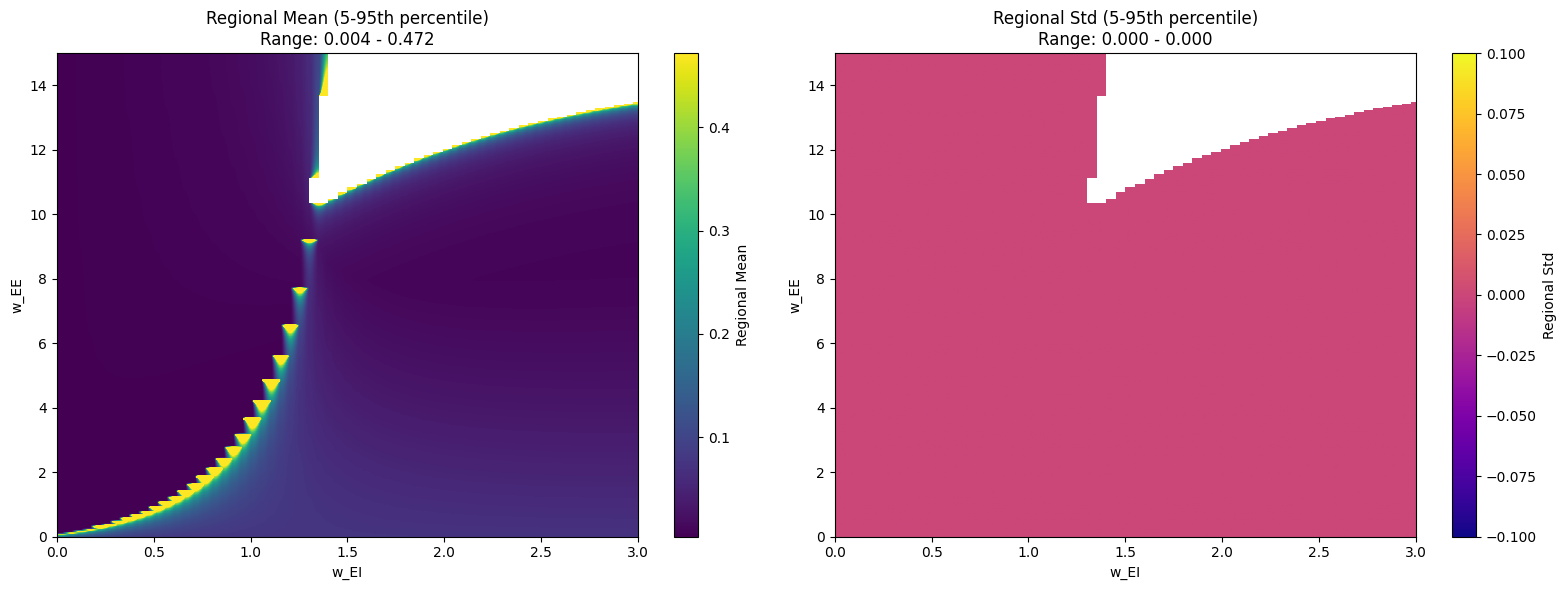

COMPREHENSIVE SUMMARY STATISTICS

Regional Mean:
  Full Range: 0.0033 - 50.7212
  5-95th percentile: 0.0037 - 0.4719
  Median: 0.0167
  Outliers below 5th percentile: 166 points
  Outliers above 95th percentile: 166 points

Regional Std:
  Full Range: 0.0000 - 0.0000
  5-95th percentile: 0.0000 - 0.0000
  Median: 0.0000
  Outliers below 5th percentile: 0 points
  Outliers above 95th percentile: 0 points

Visualization Note: Heatmaps show 5-95th percentile range to reduce outlier impact


In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting both regional_mean and regional_std as a function of w_EE and w_EI
if 'results' in locals():
    # Create pivot tables for both mean and std
    pivot_mean = results.pivot_table(index='w_EE', columns='w_EI', values='regional_mean')
    pivot_std = results.pivot_table(index='w_EE', columns='w_EI', values='regional_std')
    
    # Handle outliers using percentile-based clipping
    def robust_percentile_limits(data, lower_percentile=5, upper_percentile=95):
        """Calculate robust limits based on percentiles to handle outliers"""
        flat_data = data.values.flatten()
        flat_data = flat_data[~np.isnan(flat_data)]  # Remove NaNs
        if len(flat_data) == 0:
            return None, None
        lower = np.percentile(flat_data, lower_percentile)
        upper = np.percentile(flat_data, upper_percentile)
        return lower, upper
    
    # Calculate robust limits for both datasets
    mean_vmin, mean_vmax = robust_percentile_limits(pivot_mean, 1, 99)
    std_vmin, std_vmax = robust_percentile_limits(pivot_std, 5, 95)
    
    # Create subplots: 2D heatmaps only (no histogram)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax1, ax2 = axes

    # Plot regional mean with robust color limits
    im1 = ax1.imshow(
        pivot_mean.values, 
        aspect='auto', 
        origin='lower',
        extent=[pivot_mean.columns.min(), pivot_mean.columns.max(), 
                pivot_mean.index.min(), pivot_mean.index.max()],
        cmap='viridis',
        vmin=mean_vmin, vmax=mean_vmax  # Clip outliers
    )
    ax1.set_xlabel('w_EI')
    ax1.set_ylabel('w_EE')
    ax1.set_title(f'Regional Mean (5-95th percentile)\nRange: {mean_vmin:.3f} - {mean_vmax:.3f}')
    plt.colorbar(im1, ax=ax1, label='Regional Mean')

    # Plot regional std with robust color limits
    im2 = ax2.imshow(
        pivot_std.values, 
        aspect='auto', 
        origin='lower',
        extent=[pivot_std.columns.min(), pivot_std.columns.max(), 
                pivot_std.index.min(), pivot_std.index.max()],
        cmap='plasma',
        vmin=std_vmin, vmax=std_vmax  # Clip outliers
    )
    ax2.set_xlabel('w_EI')
    ax2.set_ylabel('w_EE')
    ax2.set_title(f'Regional Std (5-95th percentile)\nRange: {std_vmin:.3f} - {std_vmax:.3f}')
    plt.colorbar(im2, ax=ax2, label='Regional Std')

    plt.tight_layout()
    plt.show()
    
    # Print comprehensive summary statistics
    print("="*60)
    print("COMPREHENSIVE SUMMARY STATISTICS")
    print("="*60)
    
    # Regional Mean statistics
    mean_flat = pivot_mean.values.flatten()
    mean_flat = mean_flat[~np.isnan(mean_flat)]
    print(f"\nRegional Mean:")
    print(f"  Full Range: {mean_flat.min():.4f} - {mean_flat.max():.4f}")
    print(f"  5-95th percentile: {mean_vmin:.4f} - {mean_vmax:.4f}")
    print(f"  Median: {np.median(mean_flat):.4f}")
    print(f"  Outliers below 5th percentile: {np.sum(mean_flat < mean_vmin)} points")
    print(f"  Outliers above 95th percentile: {np.sum(mean_flat > mean_vmax)} points")
    
    # Regional Std statistics  
    std_flat = pivot_std.values.flatten()
    std_flat = std_flat[~np.isnan(std_flat)]
    print(f"\nRegional Std:")
    print(f"  Full Range: {std_flat.min():.4f} - {std_flat.max():.4f}")
    print(f"  5-95th percentile: {std_vmin:.4f} - {std_vmax:.4f}")
    print(f"  Median: {np.median(std_flat):.4f}")
    print(f"  Outliers below 5th percentile: {np.sum(std_flat < std_vmin)} points")
    print(f"  Outliers above 95th percentile: {np.sum(std_flat > std_vmax)} points")
    
    # Note: Timescale statistics and histogram have been removed
    
    print(f"\nVisualization Note: Heatmaps show 5-95th percentile range to reduce outlier impact")
    print("="*60)
    
else:
    print("No 'results' variable found to plot.")
